In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [23]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [ ]:
ST_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
ST_event = EDM4hepEvent(ST_file_path, event_index=0, detector_params=detector_params)
ST_particles = ST_event.get_particles_df()
ST_hits = ST_event.get_tracker_hits_df()
ST_calo_hits = ST_event.get_calo_contributions_df()
daughters = event.get_daughters_df()

In [ ]:
ST_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
ST_event = EDM4hepEvent(ST_file_path, event_index=1, detector_params=detector_params)
ST_particles = ST_event.get_particles_df()
ST_hits = ST_event.get_tracker_hits_df()
ST_calo_hits = ST_event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root...
  Loaded 19 particles.
  Loaded 16 tracker hits.
  Loaded 101 calo hits and 238 contributions.


## Plotting

In [42]:
ST_tracker_reco_particles = ST_particles[ST_particles.index.isin(ST_hits.particle_id)]

In [43]:
ST_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,8.022988,0.105658,0.003668,0.003056,140.592569,2.560188,...,0.228517,0.004774,2606.149271,10.000558,9.89490,159,False,True,False,False
11,11,0,1493172224,-1.0,26.015327,0.000511,636.182209,-793.477354,1309.618671,0.000276,...,-0.553173,1017.022180,1017.053669,0.000751,0.00024,1,True,True,True,False


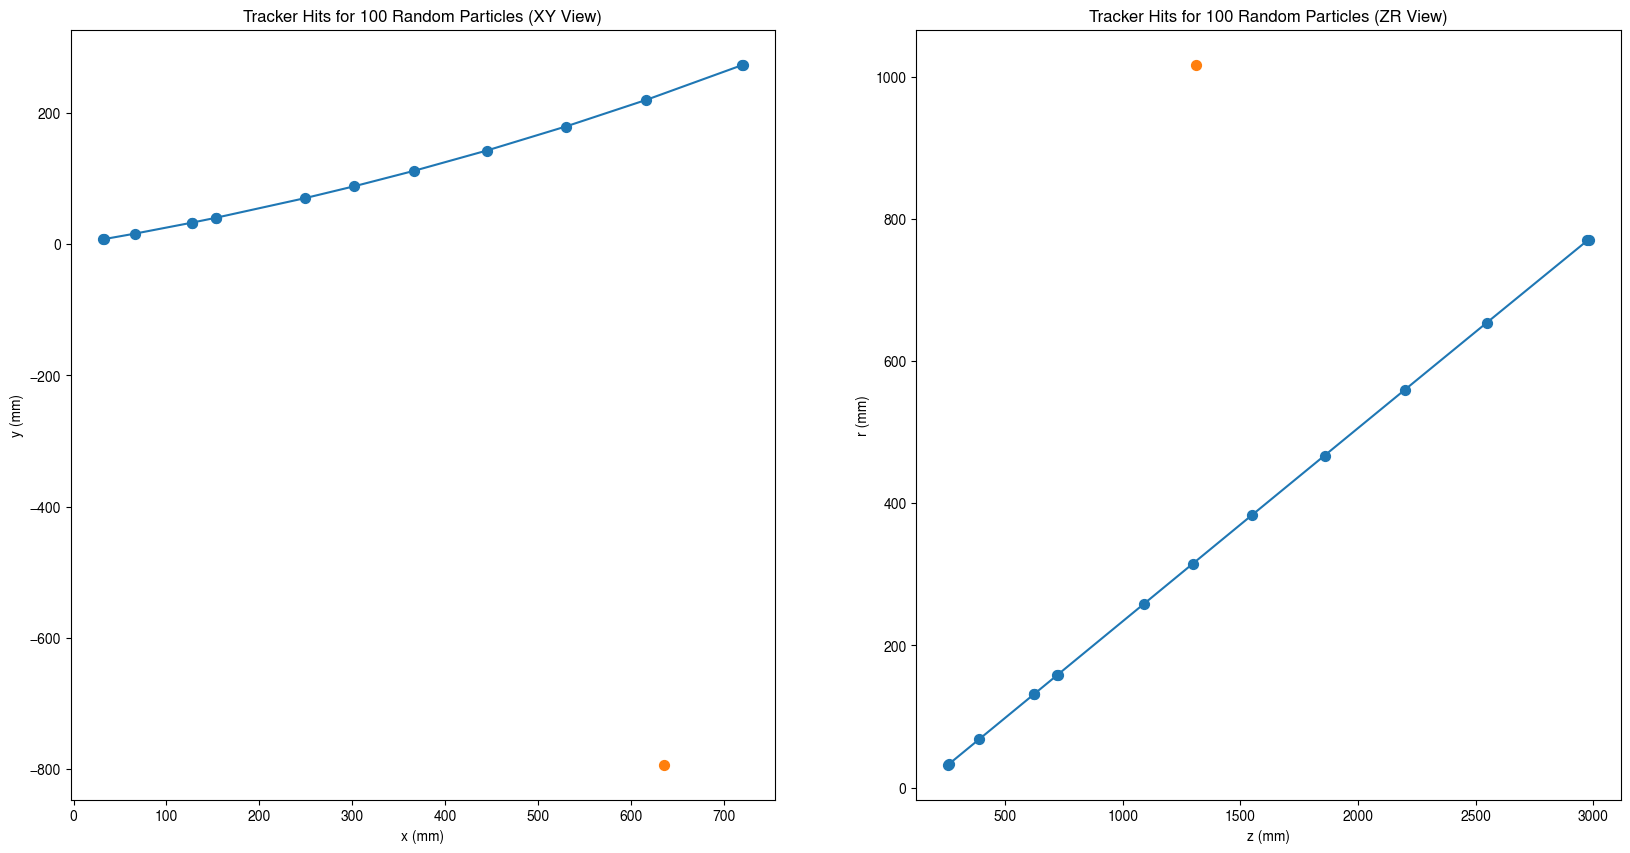

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in ST_tracker_reco_particles.index:
    particle_hits = ST_hits[ST_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

## Loading

In [45]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [46]:
MT_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root"
MT_event = EDM4hepEvent(MT_file_path, event_index=0, detector_params=detector_params)
MT_particles = MT_event.get_particles_df()
MT_hits = MT_event.get_tracker_hits_df()
MT_calo_hits = MT_event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root...
  Loaded 12 particles.
  Loaded 13 tracker hits.
  Loaded 95 calo hits and 284 contributions.


## Plotting

In [52]:
MT_tracker_reco_particles = MT_particles[MT_particles.index.isin(MT_hits.particle_id)]

In [53]:
ST_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,8.022988,0.105658,0.003668,0.003056,140.592569,2.560188,...,0.228517,0.004774,2606.149271,10.000558,9.89490,159,False,True,False,False
11,11,0,1493172224,-1.0,26.015327,0.000511,636.182209,-793.477354,1309.618671,0.000276,...,-0.553173,1017.022180,1017.053669,0.000751,0.00024,1,True,True,True,False


In [54]:
MT_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,-3.230874,0.105658,-0.017099,0.008111,1.877865,1.439086,...,1.426139,0.018925,10008.702137,10.000558,9.8949,176,False,True,False,False


In [55]:
ST_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,6737109843974,8.431952,0.479014,0,31.287374,7.460550,258.648161,2.553001,0.623295,9.647734,0.000137,0,PixelBarrelReadout,32.164570,260.640424,0.234081,0.123721,2.781594,2.627986
1,12230373015814,8.445570,0.493880,0,32.327543,7.715121,262.580003,2.551758,0.624849,9.647471,0.000328,0,PixelBarrelReadout,33.235420,264.674991,0.234273,0.125903,2.764068,2.627148
2,269450159587606,8.885972,0.477167,0,65.939173,16.166878,389.980064,2.540963,0.655421,9.645164,0.000134,0,PixelBarrelReadout,67.892138,395.845668,0.240436,0.172364,2.448815,2.624132
3,65280148744,9.689595,0.129550,0,127.021141,32.798304,622.600000,2.525076,0.717374,9.640927,0.000048,0,PixelEndcapReadout,131.187267,636.271058,0.252692,0.207671,2.261345,2.625002
4,4244637960,9.693744,0.129552,0,127.335388,32.887908,623.800000,2.525347,0.717763,9.640717,0.000080,0,PixelEndcapReadout,131.513937,637.512632,0.252754,0.207784,2.260795,2.625369
5,64307070232,10.035325,0.129549,0,153.179725,40.368247,722.600000,2.517679,0.740195,9.639493,0.000051,0,PixelEndcapReadout,158.409670,739.759679,0.257677,0.215808,2.222622,2.624232
6,4865394968,10.039474,0.129550,0,153.493047,40.460763,723.800000,2.517950,0.739305,9.639386,0.000053,0,PixelEndcapReadout,158.736224,741.001774,0.257737,0.215892,2.222231,2.624242
7,228110009369097,11.310172,0.770560,0,248.950499,70.227877,1091.033086,2.492050,0.825293,9.633751,0.000233,0,ShortStripBarrelReadout,258.666398,1121.276728,0.274951,0.232786,2.146253,2.625151
8,17330193041419,12.023181,0.259121,0,302.198213,88.430528,1297.500000,2.476730,0.873282,9.633142,0.000088,0,ShortStripEndcapReadout,314.870955,1335.159155,0.284676,0.238073,2.123587,2.626179
9,17532056504347,12.887581,0.259104,0,366.217414,111.833380,1547.500000,2.453680,0.928067,9.632843,0.000151,0,ShortStripEndcapReadout,382.912391,1594.170050,0.296380,0.242567,2.104704,2.623329


In [56]:
MT_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,236810085532422,-3.122993,0.126341,0,4.580546,31.900616,3.756374,1.409082,9.882865,0.582264,0.000113,0,PixelBarrelReadout,32.227794,32.445971,1.428183,1.454763,0.116295,9.982812
1,236943246296070,-3.120108,0.129528,0,4.701798,32.753902,3.806665,1.407897,9.882977,0.581949,0.000036,0,PixelBarrelReadout,33.089651,33.307892,1.428221,1.456259,0.114789,9.982756
2,239694877493014,-3.003999,0.125436,0,9.546010,67.164142,5.830717,1.376245,9.886950,0.581449,0.000035,0,PixelBarrelReadout,67.839135,68.089247,1.429612,1.485058,0.085844,9.982275
3,243472469003302,-2.848222,0.126300,0,15.866886,113.352664,8.544969,1.332742,9.892283,0.581308,0.000030,0,PixelBarrelReadout,114.457784,114.776308,1.431722,1.496278,0.074587,9.981657
4,247939033666102,-2.660852,0.126226,0,23.209403,168.943869,11.804114,1.281990,9.898334,0.580338,0.000036,0,PixelBarrelReadout,170.530663,170.938715,1.434272,1.501687,0.069165,9.981008
5,598507988322569,-2.358241,0.203895,0,34.472051,258.765342,17.048707,1.201137,9.906284,0.577314,0.000057,0,ShortStripBarrelReadout,261.051383,261.607498,1.438359,1.505581,0.065262,9.978837
6,808909846220057,-2.030302,0.202622,0,45.856730,356.247025,22.728418,1.113929,9.915353,0.577161,0.000082,0,ShortStripBarrelReadout,359.186278,359.904659,1.442779,1.507603,0.063235,9.977728
7,1108281951654441,-1.559909,0.203457,0,60.680864,496.239899,30.870642,0.988309,9.927623,0.577410,0.000054,0,ShortStripBarrelReadout,499.936200,500.888412,1.449119,1.509125,0.061710,9.976695
8,1424120961701945,-1.031717,0.202905,0,75.216379,653.643951,40.016210,0.848024,9.939783,0.575295,0.000055,0,ShortStripBarrelReadout,657.957384,659.173130,1.456228,1.510052,0.060781,9.975893
9,598112851332620,-0.502201,0.254739,0,87.552971,811.608598,49.153110,0.705463,9.950841,0.574979,0.000076,0,LongStripBarrelReadout,816.317364,817.795859,1.463336,1.510656,0.060177,9.975817


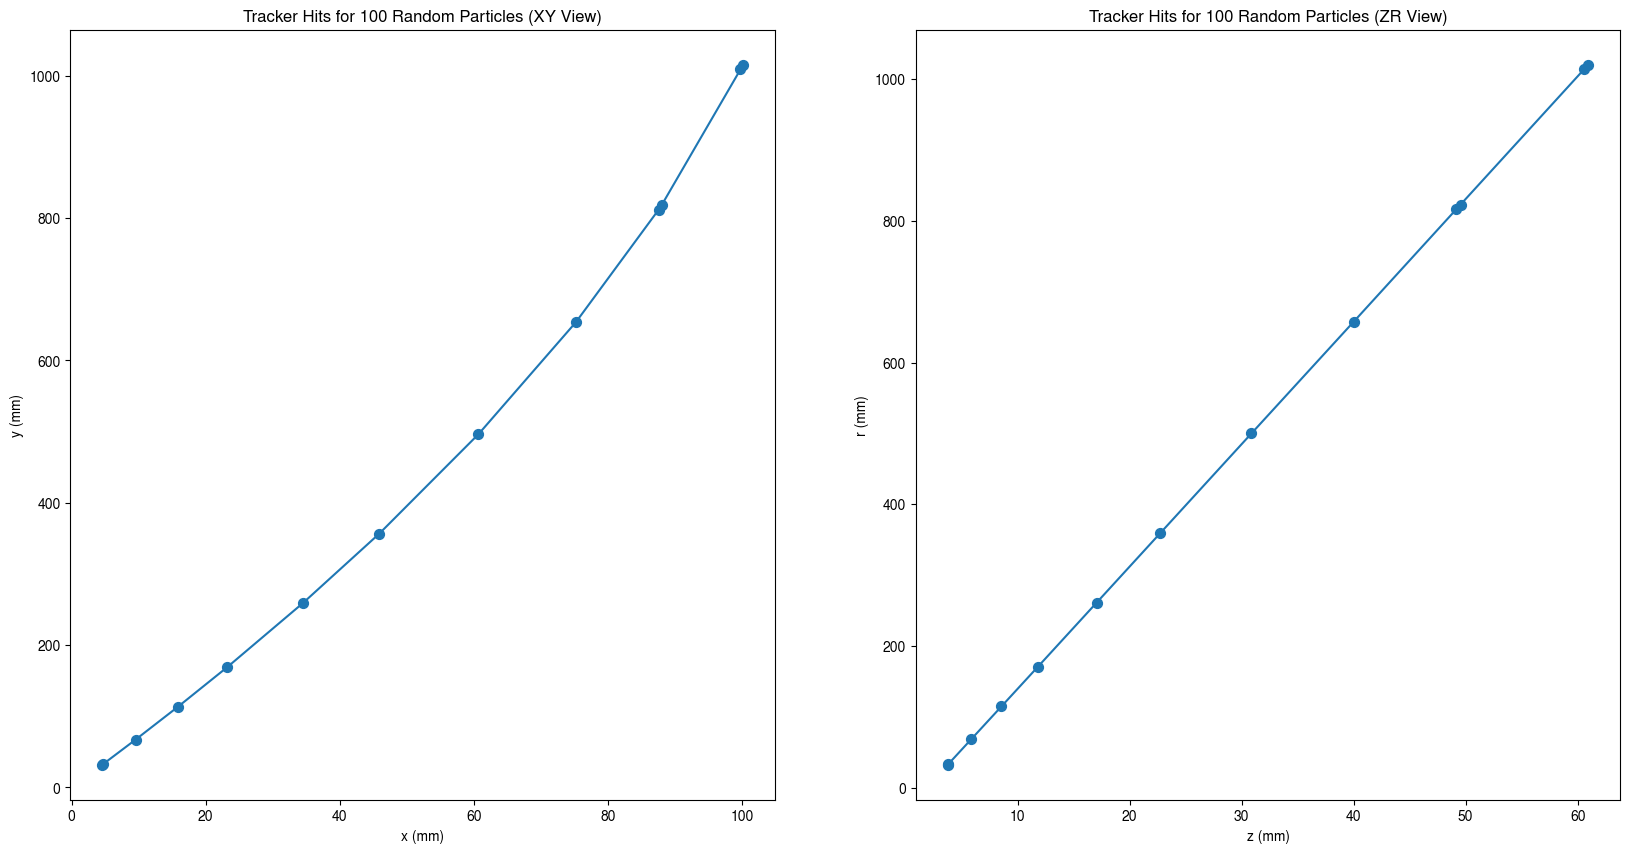

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in MT_tracker_reco_particles.index:
    particle_hits = MT_hits[MT_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()